# Portfolio Metrics

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import contextlib
import io
from copulae import GaussianCopula, StudentCopula

In [2]:
tickers = [
    "SPY", "QQQ", "DFAI", "META", "JPM", "MSFT",
    "AMZN", "NFLX", "GOOG", "ORCL", 
    "GLD", "COST", "VDC", "XLU"
]

years = 5
end_date = date.today()
start_date = end_date - timedelta(days=years * 365)

In [3]:
def get_daily_bars(symbols, start_date, end_date):
    """
    Fetch daily OHLCV data from Yahoo Finance using yfinance.

    Returns:
        data: long DataFrame with columns:
              symbol, open, high, low, close, adj_close, volume
        close_prices: wide DataFrame of close prices by symbol
    """

    raw = yf.download(
        tickers=symbols,
        start=start_date.isoformat(),
        end=end_date.isoformat(),
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        progress=True,
        threads=True
    )

    all_dfs = []

    for symbol in symbols:
        try:
            df = raw[symbol].copy()
        except KeyError:
            print(f"No data returned for {symbol}")
            continue

        if df.empty:
            print(f"No data returned for {symbol}")
            continue

        df = df.rename(columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })

        df["symbol"] = symbol
        df.index.name = "timestamp"

        df = df[["symbol", "open", "high", "low", "close", "adj_close", "volume"]]
        all_dfs.append(df)

    data = pd.concat(all_dfs).sort_index()

    close_prices = data.pivot_table(
        values="close",
        index=data.index,
        columns="symbol"
    )

    return data, close_prices


data, close_prices = get_daily_bars(tickers, start_date, end_date)

print(close_prices.tail())

[*********************100%***********************]  14 of 14 completed

symbol            AMZN        COST       DFAI         GLD        GOOG  \
timestamp                                                               
2026-07-06  244.160004  950.250000  41.959999  382.130005  364.899994   
2026-07-07  245.979996  947.500000  41.549999  377.489990  363.619995   
2026-07-08  243.619995  953.130005  41.189999  374.450012  358.709991   
2026-07-09  247.039993  912.969971  41.369999  378.179993  356.239990   
2026-07-10  245.339996  916.250000  41.580002  377.010010  355.029999   

symbol             JPM        META        MSFT       NFLX        ORCL  \
timestamp                                                               
2026-07-06  337.720001  600.289978  386.739990  76.019997  143.759995   
2026-07-07  339.220001  615.580017  388.839996  76.180000  141.600006   
2026-07-08  330.619995  603.119995  383.339996  75.589996  140.490005   
2026-07-09  335.470001  631.479980  384.359985  75.470001  144.220001   
2026-07-10  336.470001  669.210022  385.100006  73

## Helper Functions

In [4]:
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = prices / roll_max - 1
    return drawdown.min()

In [19]:
def num_params(cop, family):
    family = family.lower()
    d = cop.dim

    n_correlations = d * (d - 1) // 2

    if family == "gaussian":
        return n_correlations

    elif family == "student_t":
        return n_correlations + 1  # correlations + degrees of freedom

    else:
        raise ValueError(f"Unsupported copula family: {family}")

In [20]:
def extract_params(cop, family):
    family = family.lower()

    if family == "gaussian":
        rho_vec = np.asarray(cop.params)

        return {
            "rho": rho_vec.tolist(),
            "sigma": cop.sigma.tolist()
        }

    elif family == "student_t":
        rho_vec = np.asarray(cop.params.rho)

        return {
            "df": float(cop.params.df),
            "rho": rho_vec.tolist(),
            "sigma": cop.sigma.tolist()
        }

    else:
        raise ValueError(f"Unsupported copula family: {family}")

In [21]:
class Portfolio:
    '''
    Fields:
        self.tickers is a list of security tickers in the portfolio
        self.weights (optional) is a dictionary with ticker keys and portfolio weight values
        self.data is a DataFrame of price data for the securities in the portfolio

    '''

    def __init__(self, tickers, df, weights={}):
        self.tickers = tickers
        self.weights = weights
        self.data = df


    def holding_data(self, holding):
        df = self.data
        if holding != 'all':
            df = df[holding]
        return df


    def returns(self, holding='all', log=True):
        '''
        The daily log returns (i.e. log(P[t]/P[t-1]) = log(P[t]) - log(P[t-1]) )
        or the daily ordinary returns if log=False (i.e. P[t]/P[t-1] - 1 ).
        '''
        df = self.holding_data(holding)
        if log:
            return np.log(df).diff().dropna()
        else:
            return df.pct_change().dropna()
        

    def uni_summary(self, holding='all', log=True, tail=0.05):
        '''
        Returns a univariate summary of the returns of each security (individually), including:
            - the annualized mean and volatility, 
            - the skew and excess kurtosis, and 
            - some tail risk metrics (VaR, ES/CVaR, MaxDD).
        '''
        df = self.returns(holding=holding, log=log)
        means = df.mean()

        d = {}
        if log:
            d['Mean (Ann.)'] = means * 252
        else: 
            d['Mean (Ann.)'] = (1 + means)**252 - 1 
            # Note: this is equivalent to the expression in the log=True case
            #       although we break up the cases to take advantage of the
            #       simplified formula for log=True.
        d['Volatility (Ann.)'] = df.std() * np.sqrt(252)
        d['Skew'] = df.skew()
        d['Kurtosis (Excess)'] = df.kurtosis()
        d[f'VaR({tail*100:.1f}%)'] = df.quantile(tail) 
        d[f'ES({tail*100:.1f}%)'] = df.apply(lambda col: col[col <= col.quantile(tail)].mean())
        d[f'MaxDD'] = max_drawdown( (1+df).cumprod() )

        return pd.DataFrame(d).T
    

    def dependence(self, type="corr", holding="all", log=True, tail=0.05):
        """
        Dependence measures between return series.

        type options:
            - "corr": Pearson correlation
            - "cov": covariance
            - "spearman": rank correlation
            - "kendall": Kendall's tau
            - "lower_tail": empirical lower tail dependence
            - "upper_tail": empirical upper tail dependence
            - "all": dictionary of several dependence measures
        """

        df = self.returns(holding=holding, log=log).dropna()

        if type == "corr":
            return df.corr(method="pearson")
        elif type == "cov":
            return df.cov()
        elif type == "spearman":
            return df.corr(method="spearman")
        elif type == "kendall":
            return df.corr(method="kendall")
        elif type in ["lower_tail", "upper_tail"]:
            ranks = df.rank(method="average") / (len(df) + 1)
            out = pd.DataFrame(
                np.eye(len(df.columns)),
                index=df.columns,
                columns=df.columns
            )
            for i in df.columns:
                for j in df.columns:
                    if i == j:
                        continue
                    if type == "lower_tail":
                        # P(U_i <= q | U_j <= q)
                        numerator = ((ranks[i] <= tail) & (ranks[j] <= tail)).mean()
                        denominator = (ranks[j] <= tail).mean()
                    else:
                        # P(U_i >= 1-q | U_j >= 1-q)
                        numerator = ((ranks[i] >= 1 - tail) & (ranks[j] >= 1 - tail)).mean()
                        denominator = (ranks[j] >= 1 - tail).mean()
                    out.loc[i, j] = numerator / denominator if denominator > 0 else np.nan
            return out
        elif type == "all":
            return {
                "pearson_corr": df.corr(method="pearson"),
                "spearman_corr": df.corr(method="spearman"),
                "kendall_tau": df.corr(method="kendall"),
                "covariance": df.cov(),
                f"lower_tail_{tail}": self.dependence(
                    type="lower_tail", holding=holding, log=log, tail=tail
                ),
                f"upper_tail_{tail}": self.dependence(
                    type="upper_tail", holding=holding, log=log, tail=tail
                )
            }
        else:
            raise ValueError(
                "type argument must be one of: 'corr', 'cov', 'spearman', 'kendall', "
                "'lower_tail', 'upper_tail', or 'all'"
            )
        
    def margin_fit(self, holding="all", log=True): 
        """
        Fit marginal distributions to individual security returns. 

        Families:
            - Normal
            - Student-t
            - Laplace (Double Exponential)
            - GEV (Generalized Extreme Value)
        """
        
        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 1:
            raise ValueError("Need at least one asset to fit marginals.")

        results = []

        for col in df.columns:
            series = df[col].dropna()
            n = len(series)

            # Fit Normal distribution
            mu, sigma = series.mean(), series.std()
            ll_normal = np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((series - mu)**2) / (2 * sigma**2))
            aic_normal = -2 * ll_normal + 2 * 2  # 2 parameters: mu and sigma
            bic_normal = -2 * ll_normal + np.log(n) * 2

            # Fit Student-t distribution
            from scipy.stats import t 
            params_t = t.fit(series)
            ll_t = np.sum(t.logpdf(series, *params_t))
            aic_t = -2 * ll_t + 2 * len(params_t)
            bic_t = -2 * ll_t + np.log(n) * len(params_t)

            # Fit Laplace distribution
            from scipy.stats import laplace
            params_laplace = laplace.fit(series)
            ll_laplace = np.sum(laplace.logpdf(series, *params_laplace))
            aic_laplace = -2 * ll_laplace + 2 *len(params_laplace)
            bic_laplace = -2 * ll_laplace + np.log(n) * len(params_laplace)

            # Fit GEV distribution
            from scipy.stats import genextreme
            params_gev = genextreme.fit(series)
            ll_gev = np.sum(genextreme.logpdf(series, *params_gev))
            aic_gev = -2 * ll_gev + 2 * len(params_gev)
            bic_gev = -2 * ll_gev + np.log(n) * len(params_gev) 

            results.append({
                "Asset": col,
                "Normal": {"mu": mu, "sigma": sigma, "loglik": ll_normal, "aic": aic_normal, "bic": bic_normal},
                "Student-t": {"params": params_t, "loglik": ll_t, "aic": aic_t, "bic": bic_t},
                "Laplace": {"params": params_laplace, "loglik": ll_laplace, "aic": aic_laplace, "bic": bic_laplace}, 
                "GEV": {"params": params_gev, "loglik": ll_gev, "aic": aic_gev, "bic": bic_gev},
                "Best-Fit-AIC": None,
                "Best-Fit-BIC": None
            })

            results[-1]["Best-Fit-AIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["aic"])
            results[-1]["Best-Fit-BIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["bic"])

        return pd.DataFrame(results)
    
    def copula_fit(self, holding="all", log=True, criterion="bic"):
        """
        Fit a copula to portfolio returns.

        Families:
            - Gaussian
            - Student-t
        """

        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 2:
            raise ValueError("Need at least two assets to fit a copula.")

        criterion = criterion.lower()
        if criterion not in ["aic", "bic"]:
            raise ValueError("criterion must be 'aic' or 'bic'.")

        d = df.shape[1]

        models = {
            "gaussian": GaussianCopula(dim=d),
            "student_t": StudentCopula(dim=d)
        }

        results = []

        for name, cop in models.items():
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    cop.fit(df, to_pobs=True)

                u = cop.pobs(df)
                ll = cop.log_lik(u, to_pobs=False)
                k = num_params(cop, name)
                n = len(df)

                aic = -2 * ll + 2 * k
                bic = -2 * ll + np.log(n) * k

                params = extract_params(cop, name)

                results.append({
                    "family": name,
                    "loglik": ll,
                    "n_params": k,
                    "aic": aic,
                    "bic": bic,
                    "params": params,
                    "model": cop,
                    "error": None
                })

            except Exception as e:
                results.append({
                    "family": name,
                    "loglik": np.nan,
                    "n_params": np.nan,
                    "aic": np.nan,
                    "bic": np.nan,
                    "params": None,
                    "model": None,
                    "error": repr(e)
                })

        summary = (
            pd.DataFrame(results)
            .drop(columns=["model"], errors="ignore")
            .sort_values(criterion, na_position="last")
            .reset_index(drop=True)
        )

        valid = [r for r in results if r["model"] is not None]

        if not valid:
            raise RuntimeError("No copula models successfully fit.")

        best = min(valid, key=lambda r: r[criterion])

        return {
            "summary": summary,
            "best_family": best["family"],
            "best_params": best["params"],
            "best_model": best["model"],
            "all_results": results,
            "assets": list(df.columns),
            "n_obs": len(df),
            "dimension": d,
            "criterion": criterion
        }

        



## Testing out the `Portfolio` class (*without* weights)

In [22]:
# create instance of Portfolio class
p = Portfolio(tickers=tickers, df=close_prices)

In [9]:
summary = p.uni_summary()
summary

symbol,AMZN,COST,DFAI,GLD,GOOG,JPM,META,MSFT,NFLX,ORCL,QQQ,SPY,VDC,XLU
Mean (Ann.),0.055723,0.162638,0.068573,0.161242,0.201025,0.151906,0.128447,0.065980,0.062603,0.096334,0.139478,0.109830,0.044745,0.067807
Volatility (Ann.),0.356702,0.229604,0.160606,0.184259,0.313695,0.245165,0.449646,0.270127,0.448603,0.414718,0.227508,0.171792,0.133353,0.173605
Skew,-0.097970,-0.823533,0.021196,-0.872925,0.006454,-0.068444,-1.111369,-0.076217,-3.052662,1.340508,0.030677,0.147712,-0.443134,-0.311544
Kurtosis (Excess),4.787128,8.620069,4.162236,8.455874,3.301637,4.728471,24.120316,3.552067,49.952228,20.093080,4.417223,7.903699,4.139424,1.758730
VaR(5.0%),-0.033860,-0.021642,-0.015813,-0.017878,-0.029144,-0.024495,-0.040843,-0.027325,-0.035777,-0.039010,-0.023331,-0.016843,-0.013312,-0.017659
ES(5.0%),-0.052018,-0.034169,-0.022365,-0.027317,-0.043916,-0.036612,-0.064098,-0.039021,-0.062770,-0.058990,-0.033124,-0.025024,-0.018785,-0.024995
MaxDD,-0.615481,-0.326488,-0.308576,-0.281145,-0.482305,-0.429732,-0.817506,-0.410032,-0.810447,-0.625980,-0.390297,-0.270605,-0.183998,-0.296246


<Axes: title={'center': 'Individual Returns (Daily)'}, xlabel='Date', ylabel='Return (%)'>

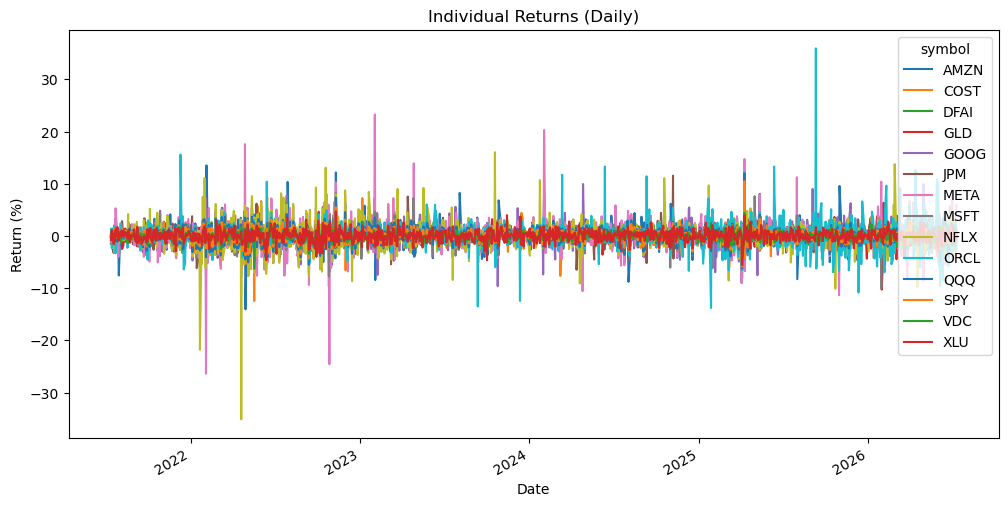

In [10]:
(p.returns(holding='all', log=False)*100).plot(
    title="Individual Returns (Daily)",
    xlabel="Date",
    ylabel="Return (%)",
    figsize=(12, 6)
)

<Axes: title={'center': 'Individual Returns (Cumulative)'}, xlabel='Date', ylabel='Cumulative Return (%)'>

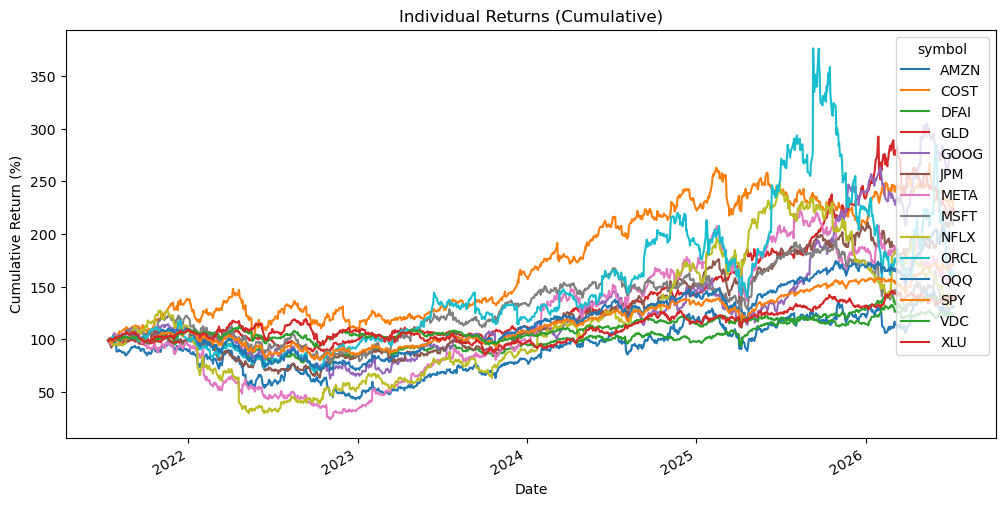

In [11]:
p.data.apply(lambda x: 100*x/x.iloc[0]-1).plot(
    title="Individual Returns (Cumulative)",
    xlabel="Date",
    ylabel="Cumulative Return (%)",
    figsize=(12, 6)
)

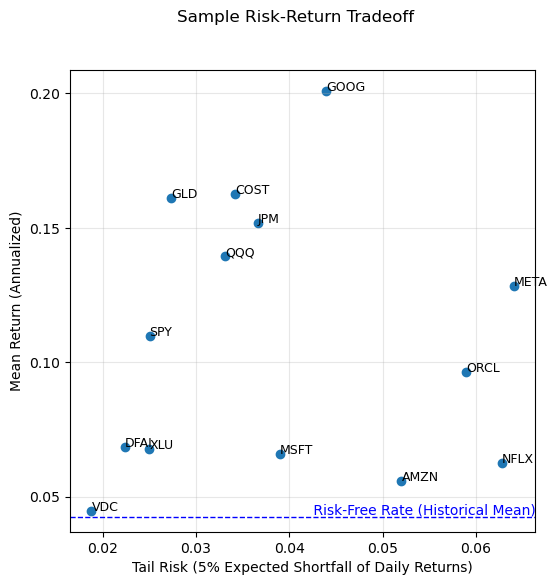

In [12]:
## make this plot a method in the class
fig, ax = plt.subplots(figsize=(6, 6))
x = -summary.loc['ES(5.0%)'] 
y = summary.loc['Mean (Ann.)']
ax.scatter(x=x, y=y)
texts = []
for t in summary.columns:
    texts.append(ax.text(x[t], y[t], t, fontsize=9))
ax.set_xlabel('Tail Risk (5% Expected Shortfall of Daily Returns)') ; ax.set_ylabel('Mean Return (Annualized)')
fig.suptitle(f'Sample Risk-Return Tradeoff')
ax.grid(True, alpha=0.3)
rf = 0.0425 # historical avg risk-free rate (10yr treasury YTM)
ax.axhline(y=rf, color='blue', linestyle='--', linewidth=1)
ax.text(
    ax.get_xlim()[1],
    rf,
    " Risk-Free Rate (Historical Mean)",
    color="blue",
    va="bottom",
    ha="right",
    fontsize=10
)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.05))

plt.show()


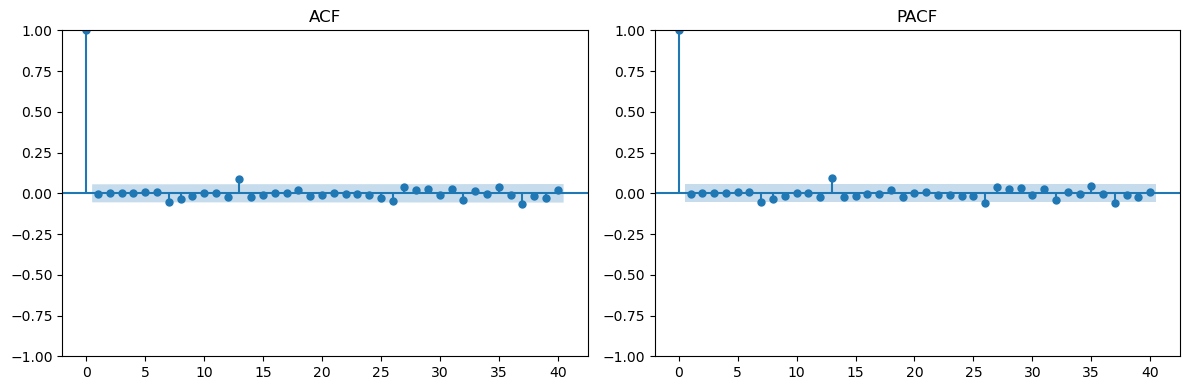

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Plot ACF and PACF for returns
log_returns = p.returns(log=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(log_returns.iloc[:, 0], lags=40, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(log_returns.iloc[:, 0], lags=40, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

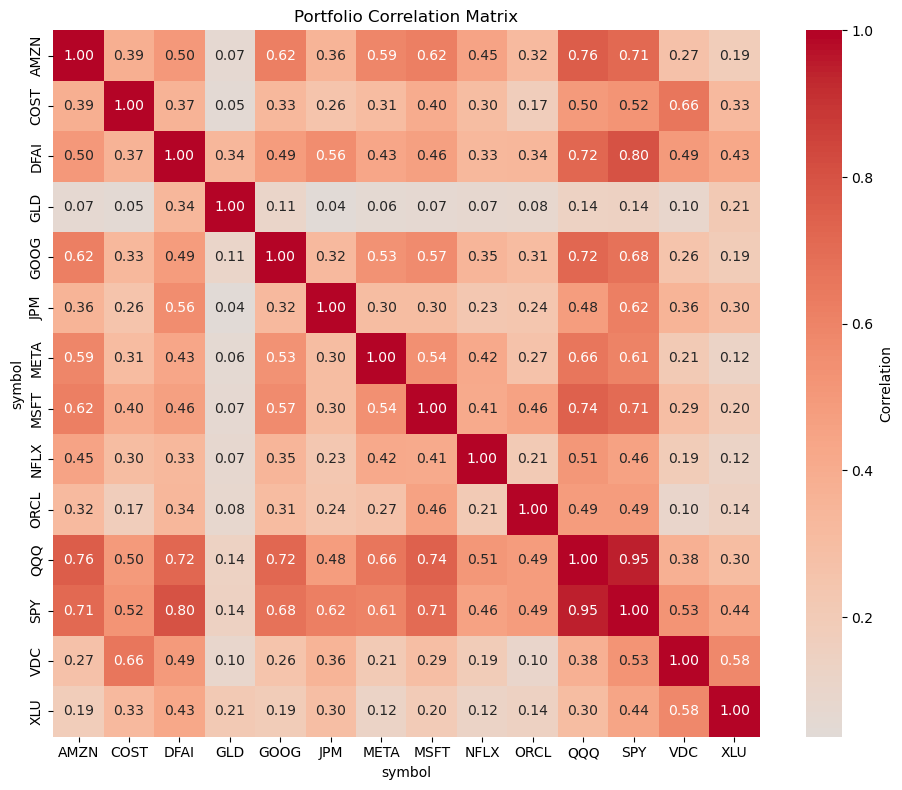

In [14]:
import seaborn as sns

corr_matrix = p.dependence()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Portfolio Correlation Matrix')
plt.tight_layout()
plt.show()

In [23]:
fit = p.copula_fit(criterion="bic") # note: this can take a couple minutes for the student-t copula

In [24]:
fit["summary"]

,family,loglik,n_params,aic,bic,params,error
0,student_t,6925.977614,92,-13667.955229,-13195.618607,"{'df': 9.373572884469155, 'rho': [0.3958697296...",None
1,gaussian,6491.861889,91,-12801.723777,-12334.521249,"{'rho': [0.3834308275980515, 0.504664592950649...",None


From Sklar's theorem, for a random $d$-vector $X=(X_1,\dots,X_d)^\top$ with joint CDF $F$, copula $C$, and margins $F_i$ for $X_i$, the CDF can be decomposed into
$$
F(x) = C\Big(F_1(x_1),\dots,F_d(x_d) \Big) \quad \forall x\in\mathbb{R}^d
$$
and hence the density $f$ satisfies
$$
f(x) = {\small \frac{d}{dx}} F(x) =  c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) \quad \forall x\in\mathbb{R}^d
$$
where $c$ is the density of the copula, i.e., 
$$ 
c(u) = {\small \frac{\partial^d}{\partial u_1 \cdots \partial u_d }} C(u)
$$

The $t$ copula with $\nu>0$ degrees of freedom and correlation matrix $P\in\mathbb{R}^{d\times d}$ can be represented by
$$
C^t_{\nu, P}(u) = \int_{-\infty}^{t^{-1}_\nu(u_1)} \cdots \int_{-\infty}^{t^{-1}_\nu(u_d)} \frac{\Gamma(\frac{\nu + d}{2})}{\Gamma(\nu/2) \sqrt{(\pi\nu)^d \det P}} 
\Big(1 + \frac{1}{\nu} x^\top P^{-1} x \Big)^{-(\nu + d)/{2}} dx \quad\quad \forall u\in(0,1)^d
$$
where $t^{-1}_\nu$ is the quantile function of a univariate $t_{(\nu)}$ distribution. 

Source: ("The $t$ Copula and Related Copulas") https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/303eb11b4d617b79c1257b0800744575/$FILE/t%20copula%20demarta%20mcneil.pdf

Let $R=w^\top X$ be the portfolio return random variable, where $w\in[0,1]^d$ is the vector of (fixed) portfolio weights.

The CDF is of $R$ is then 
$$
\begin{aligned}
G(r) &= \mathbb{P}(R\leq r) = \int_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x)dx = \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x) dx \\
&= \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) dx
\end{aligned}
$$


In [25]:
fit["best_family"] 

'student_t'

In [26]:
student_params = fit["summary"].loc[fit["summary"]["family"] == "student_t", "params"].iloc[0]
student_params

{'df': 9.373572884469155,
 'rho': [0.39586972964911304,
  0.5204679403089183,
  0.07265828650722987,
  0.660454950381223,
  0.3507170366844056,
  0.6405781362980888,
  0.6684562063673867,
  0.5267193884114103,
  0.4314430159478954,
  0.7839013265957875,
  0.7340879096877408,
  0.25632070474082924,
  0.17442656361390052,
  0.3651099189777962,
  0.043697910712317684,
  0.33947950219392925,
  0.2406892648607851,
  0.37653666959843257,
  0.4387665353086686,
  0.38417787848990387,
  0.2550423156401322,
  0.5107617870513282,
  0.5299292613721531,
  0.6308015293246803,
  0.32016813300010966,
  0.331854621949946,
  0.505516231019247,
  0.5435939225678311,
  0.511335483232745,
  0.4974579382342596,
  0.40193976793982517,
  0.4081098495060832,
  0.6972146053258769,
  0.7840700074156804,
  0.4715750353752721,
  0.3920744937395893,
  0.1138388588034696,
  0.022636894430734297,
  0.07234960163321184,
  0.07117371758765703,
  0.08867187308153208,
  0.08048346846488708,
  0.11257168697719112,
  0.122

In [191]:
dim = p.data.shape[1]

df = float(student_params["df"])
rho = np.asarray(student_params["rho"], dtype=float).ravel()

student_t_copula = StudentCopula(dim=dim)
student_t_copula.params = np.concatenate(([df], rho))

def student_t_copula_pdf(u):
    u = np.asarray(u, dtype=float)
    if u.ndim == 1:
        u = u.reshape(1, -1)
    return student_t_copula.pdf(u)


def student_t_copula_cdf(u):
    u = np.asarray(u, dtype=float)
    if u.ndim == 1:
        u = u.reshape(1, -1)
    return student_t_copula.cdf(u)

In [193]:
margins = p.margin_fit()

In [194]:
margins

,Asset,Normal,Student-t,Laplace,GEV,Best-Fit-AIC,Best-Fit-BIC
0,AMZN,"{'mu': 0.00021878576898424972, 'sigma': 0.0224...","{'params': (4.265120519445272, 0.0004608453226...","{'params': (0.0003428575146782187, 0.016144049...","{'params': (1.339578966290028, -0.033508391661...",Student-t,Student-t
1,COST,"{'mu': 0.0006715866271736607, 'sigma': 0.01441...","{'params': (4.043465133294979, 0.0010576375849...","{'params': (0.0009685587301015985, 0.010206808...","{'params': (0.2274090099553745, -0.00490713661...",Student-t,Student-t
2,DFAI,"{'mu': 0.00027256685427485265, 'sigma': 0.0101...","{'params': (5.098691857972697, 0.0004011275912...","{'params': (0.0006761483340425034, 0.007457502...","{'params': (0.1709570413036755, 0.000761924765...",Student-t,Student-t
3,GLD,"{'mu': 0.000631346125580862, 'sigma': 0.011589...","{'params': (3.7975333409222336, 0.000865218799...","{'params': (0.0007061061978976824, 0.008166281...","{'params': (1.4025314632373655, -0.00899234502...",Student-t,Student-t
4,GOOG,"{'mu': 0.0008102670838549706, 'sigma': 0.01976...","{'params': (4.3557107828346275, 0.000962353370...","{'params': (0.0013180105706394052, 0.014345330...","{'params': (0.1892856558742811, -0.00704920385...",Student-t,Student-t
5,JPM,"{'mu': 0.0006215946278371913, 'sigma': 0.01546...","{'params': (4.0313020682070775, 0.001067240814...","{'params': (0.001024158081175841, 0.0110746845...","{'params': (1.3238448190632774, -0.01758426583...",Student-t,Student-t
6,META,"{'mu': 0.0004411928376154182, 'sigma': 0.02821...","{'params': (3.0903422534297986, 0.000772415478...","{'params': (0.0007487313381449034, 0.018024410...","{'params': (1.335967994820555, -0.005373936759...",Student-t,Student-t
7,MSFT,"{'mu': 0.0002595639724992791, 'sigma': 0.01701...","{'params': (4.182016720095632, 0.0005074494449...","{'params': (0.0003956465037200374, 0.012267618...","{'params': (1.3439262399121716, -0.01265158300...",Laplace,Laplace
8,NFLX,"{'mu': 0.0002512882547473961, 'sigma': 0.02823...","{'params': (3.041654205183593, 0.0003793089521...","{'params': (0.00011859647029499598, 0.01766948...","{'params': (0.2611871613859127, -0.01047912901...",Student-t,Student-t
9,ORCL,"{'mu': 0.0004309408775248699, 'sigma': 0.02613...","{'params': (2.662973871163283, 0.0004500075426...","{'params': (0.0007861369530099971, 0.016726876...","{'params': (0.08844833221348103, -0.0108910048...",Student-t,Student-t


### `SimReturnsVector()`
1. Simulate $V\sim C$ via $V_i=C^{-1}(U_i)$ for $i=1,\dots,d$ where $U\overset{iid}{\sim}\text{Unif}(0,1)$
2. Simulate and return $X\sim F$ via $X_i=F_i^{-1}(V_i)$ for $i=1,\dots,d$

### `SimPortfolioReturn()`
1. Simulate $X=$`SimReturnsVector()`
2. Return $R=w^\top X$

### `SimShortfall()`
1. Simulate $R=$`SimPortfolioReturn()`
2. If $R\leq \text{VaR}_\alpha(R)$, (accept the sample) return $R$. Otherwise, return None (skip to next sample)

In [ ]:
# this is what getting marginal quantile functions looks like
from scipy.stats import norm, t, laplace, genextreme

params = margins.loc[margins["Asset"] == "SPY", "Student-t"].iloc[0]["params"]
qt = lambda x: t.ppf(x, df=params["df"], loc=params["loc"], scale=params["scale"])


## Next Features for this Project
CAN DO NOW:
- fit margins to portfolio (already strated sketch of this method)
    - use margins + copula to (statically) estimate things like VaR and ES *for the portfolio random vector* $y=x^\top w$
    - TODO for this:
        - make joint_pdf() and joint_cdf method which creates the joint PDF and CDF using the margins and copula 
        - make risk_measures() method which uses the joint density to output key risk measures like ES, VaR, MaxDD, etc.
            - this will rely on portfolio weights (as opposed to individual security risks as prev done)
            - UP TO HERE COULD STAND ALONE AS A PARAMETRIC EQUITY RISK ENGINE BTW (?)

AFTER FINISHING MIT FACTOR MODELING STUDYING:
- linear factor models
    - understanding portfolio risks/drivers
    - parameter reduction for covariance estimation
    - stress testing (e.g. VaR / ES under different macro shock/equity market scenarios)
- portfolio optimization
    - Mean-Var optimiziation (with different covariance matrix estimates incl. the factor model est.)
    - Mean-ES optimization
- volatility models
    - GARCH (+ dynamic mean return model -- look for examples online of what ppl use / look at Mike M's PhD paper)
    - Stochastic Vol model (Heston) - which also models returns as a whole
    - VaR / ES forecasting from the model
- genAI feature(s): 
    - RAG over market news for explaining recent portfolio movements

SEPARATE PROJECT:
- market bubble / market crash predictor
    - can try a variety of methods and/or an ensemble of them
        - the graph theory one or whatever from algebraic continuation channel,
        - the XLU/SPY z-score thiing or whatever from iPhone notes on PROJECTS

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

In [ ]:
# quantities and weights of each holding
q = {
    "DFAI":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SCHQ":45
}
w = {k: v/sum(q.values()) for k, v in q.items()}

# tickers
my_pft = list(w.keys())

# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=close_prices, weights=w)

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

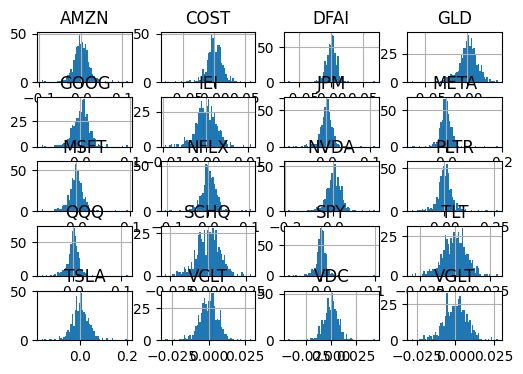

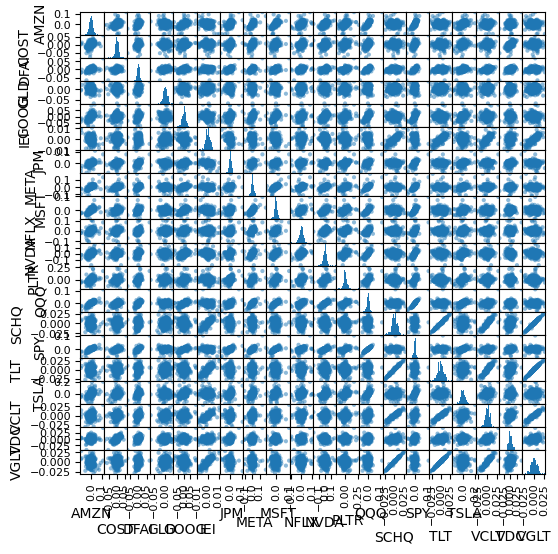

In [ ]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()